# E-Commerce Customer Segmentation using RFM Analysis

This project analyzes e-commerce customer behavior using SQL, Python, and Power BI.

The objective is to understand customer purchasing patterns and segment customers based on Recency, Frequency, and Monetary (RFM) analysis.

In [34]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import datetime as dt

In [35]:
customers = pd.read_csv('../data/olist_customers_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')

print("Data Loaded Successfully")

Data Loaded Successfully


## Data Loading

In this step, I loaded the main datasets required for the analysis, including customer, order, order item, payment, and product data.

In [36]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [37]:
customers.isnull().sum()
payments.isnull().sum()
orders.isnull().sum()
products.isnull().sum()
order_items.isnull().sum()


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [38]:
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

In [39]:
products['product_category_name'] = products['product_category_name'].fillna('unknown')

In [40]:
products['product_weight_g'] = products['product_weight_g'].fillna(products['product_weight_g'].median())

products['product_length_cm'] = products['product_length_cm'].fillna(products['product_length_cm'].median())

products['product_height_cm'] = products['product_height_cm'].fillna(products['product_height_cm'].median())

products['product_width_cm'] = products['product_width_cm'].fillna(products['product_width_cm'].median())

In [ ]:
products = products.drop(columns=['product_name_lenght','product_description_lenght','product_photos_qty'])

In [42]:
orders = orders[orders['order_status'] == 'delivered']

In [43]:
orders = orders.dropna(subset=['order_approved_at','order_delivered_carrier_date','order_delivered_customer_date'])

In [44]:
# products.isnull().sum()
orders.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

## Handling Missing Values in Orders Table

Missing values were observed in delivery-related columns such as approval and delivery timestamps.

These missing values represent real-world scenarios such as pending or cancelled orders.

To ensure accurate analysis, only delivered orders were considered for further analysis, and no artificial imputation was performed.

In [45]:
from sqlalchemy import create_engine

In [46]:
engine = create_engine("sqlite:///../ecommerce.db")
print("Database created successfully ")

Database created successfully 


In [47]:
customers.to_sql('customers', con=engine, if_exists='replace', index=False)
orders.to_sql('orders', con=engine, if_exists='replace', index=False)
order_items.to_sql('order_items', con=engine, if_exists='replace', index=False)
payments.to_sql('payments', con=engine, if_exists='replace', index=False)
products.to_sql('products', con=engine, if_exists='replace', index=False)

print("All tables stored in SQLite successfully ")

All tables stored in SQLite successfully 


## Database Setup

We created a SQLite database using SQLAlchemy to simulate a real-world database environment.

This allows us to store structured data and perform SQL queries directly from Python, mimicking how data analysts work in production systems.

In [48]:
pd.read_sql("select name from sqlite_master where type='table';",con=engine)

,name
0,customers
1,orders
2,order_items
3,payments
4,products


In [49]:
pd.read_sql(" select * from customers limit 5;",engine)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [50]:
query = """
SELECT
    o.order_id,
    c.customer_unique_id,
    o.order_purchase_timestamp,
    p.payment_value
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN payments p
    ON o.order_id = p.order_id
LIMIT 10;
"""

result = pd.read_sql(query, con=engine)
result.head()

,order_id,customer_unique_id,order_purchase_timestamp,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2.00
1,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,18.12
2,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,179.12


### Explanation:
In this step, we joined orders, customers, and payments tables to create a unified dataset.

This helps us understand:
- Which customer placed which order
- How much payment was made
- When the order was placed

This combined dataset will be used for further analysis like RFM segmentation.

In [51]:
rfm_query = """
SELECT
    c.customer_unique_id,
    MAX(o.order_purchase_timestamp) AS last_purchase_date,
    COUNT(DISTINCT o.order_id) AS frequency,
    SUM(p.payment_value) AS monetary
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN payments p
    ON o.order_id = p.order_id
GROUP BY c.customer_unique_id
"""

rfm_base = pd.read_sql(rfm_query, con=engine)
rfm_base.head()

,customer_unique_id,last_purchase_date,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


# RFM(Recency, Frequency, Monetary) Base Table

#  What we did:
We aggregated customer-level data using SQL to compute recency, frequency, and monetary values.

# Output Interpretation:
- Each row represents a unique customer
- `last_purchase_date` shows the most recent order
- `frequency` indicates number of orders
- `monetary` represents total spending

This confirms successful transformation of transactional data into customer-level insights.

In [52]:
rfm_base['last_purchase_date'] = pd.to_datetime(rfm_base['last_purchase_date'])

rfm_base.head()

,customer_unique_id,last_purchase_date,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89


## Data Preparation for Recency Calculation

### What we did:
Converted the `last_purchase_date` column into datetime format to enable time-based calculations.

### Why this is important:
Recency is calculated as the number of days since the customer's last purchase, which requires date operations.

### Output Interpretation:
The dataset remains the same structurally, but the `last_purchase_date` is now in datetime format, allowing accurate time difference calculations in the next step.

In [53]:
import datetime as dt

# Get latest date in dataset
current_date = rfm_base['last_purchase_date'].max()

# Calculate recency
rfm_base['recency'] = (current_date - rfm_base['last_purchase_date']).dt.days

rfm_base.head()

,customer_unique_id,last_purchase_date,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,114
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,536
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,320
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,287


## Recency Calculation

### What we did:
We calculated the recency value for each customer by finding the difference (in days) between the latest purchase date in the dataset and each customer's last purchase date.

### Why this is important:
Recency helps identify how recently a customer has interacted with the business. Customers with lower recency values are more recent and are generally more engaged.

### Output Interpretation:
- Lower recency → recent customers (high engagement)
- Higher recency → inactive customers (low engagement)

This metric is crucial for identifying active vs. potentially churned customers.

In [54]:
rfm_base[['frequency', 'monetary']].describe()

,frequency,monetary
count,93335.000000,93335.000000
mean,1.033417,165.199917
std,0.209099,226.335837
min,1.000000,9.590000
25%,1.000000,63.050000
50%,1.000000,107.780000
75%,1.000000,182.545000
max,15.000000,13664.080000


## Frequency and Monetary Analysis

### What we did:
We analyzed the distribution of frequency (number of orders) and monetary (total spending) values using summary statistics.

### Why this is important:
This helps us understand customer behavior patterns:
- How often customers purchase
- How much they spend

### Output Interpretation:
- `frequency` shows how many orders each customer has placed
- `monetary` represents total spending by each customer

We can observe variation in both metrics, indicating the presence of low-value and high-value customers.

These variations will be useful when assigning RFM scores in the next step.

In [55]:
# giving scores to recency, frequency and monetary

rfm_base['R_score'] = pd.qcut(rfm_base['recency'], 5, labels=[5,4,3,2,1])

rfm_base['F_score'] = pd.qcut(rfm_base['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

rfm_base['M_score'] = pd.qcut(rfm_base['monetary'], 5, labels=[1,2,3,4,5])

rfm_base[['customer_unique_id', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score']].head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,536,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89,2,1,4


## RFM scoring

In this step, I converted recency, frequency and monetary values into scores from 1 to 5.

- For recency, lower value is better, so customers who purchased recently get higher score.
- For frequency, customers with more orders get higher score.
- For monetary, customers who spent more get higher score.

This helps in comparing customers easily and will be useful for customer segmentation.

In [56]:
# combine R, F, M scores into one string
rfm_base['RFM_score'] = rfm_base['R_score'].astype(str) + rfm_base['F_score'].astype(str) + rfm_base['M_score'].astype(str)

def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champion'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    else:
        return 'Normal'

rfm_base['Segment'] = rfm_base.apply(segment_customer, axis=1)

rfm_base[['customer_unique_id', 'R_score', 'F_score', 'M_score', 'Segment']].head()

,customer_unique_id,R_score,F_score,M_score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,4,1,4,Normal
1,0000b849f77a49e4a4ce2b2a4ca5be3f,4,1,1,Normal
2,0000f46a3911fa3c0805444483337064,1,1,2,Normal
3,0000f6ccb0745a6a4b88665a16c9f078,2,1,1,Normal
4,0004aac84e0df4da2b147fca70cf8255,2,1,4,Normal


## Customer Segmentation

In this step, I grouped customers into different segments based on their RFM scores.

- Champions → recent and frequent buyers
- Loyal → regular customers
- At Risk → customers who were frequent but not recent
- Normal → other customers

This helps in understanding customer behavior and identifying high-value and low-value customers.

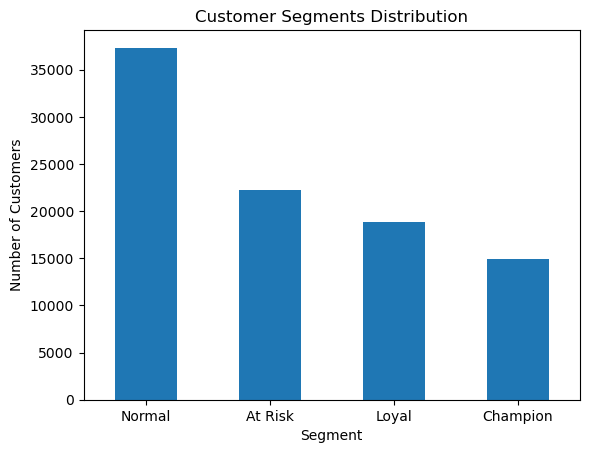

In [57]:
import matplotlib.pyplot as plt

# count customers in each segment
segment_counts = rfm_base['Segment'].value_counts()

plt.figure()
segment_counts.plot(kind='bar',rot=0)

plt.title("Customer Segments Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

Insights from Customer Segmentation

- Most customers are in the "Normal" segment, showing average engagement.
- A large number of customers are "At Risk", indicating possible churn.
- "Loyal" customers form a stable group with regular purchases.
- Fewer "Champion" customers suggest scope to improve high-value customer retention.

Business Impact:
Focus on converting Normal customers to Loyal and re-engaging At Risk customers.

In [58]:
rfm_base.to_csv('../dashboard/rfm_final.csv', index=False)

print("File saved successfully ")

File saved successfully 




In this step, I saved the final RFM dataset as a CSV file.

This dataset will be used for creating dashboards in tools like Power BI or Tableau.